# car_price_prediction

Test notebook

## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = 'c94t16yic2lpxn'
os.environ['DataZoneDomainId'] = 'dzd-65qkf4nyj0vkjv'
os.environ['DataZoneEnvironmentId'] = 'bgxe4fpqumo2dn'
os.environ['DataZoneDomainRegion'] = 'eu-central-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "c94t16yic2lpxn",
                "DataZoneDomainId": "dzd-65qkf4nyj0vkjv",
                "DataZoneEnvironmentId": "bgxe4fpqumo2dn",
                "DataZoneDomainRegion": "eu-central-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

# Car Price Prediction - Model Training and Evaluation
This notebook automates the data ingestion from S3, performs feature engineering, and trains a regression model to predict car prices.

In [0]:
import pandas as pd
import boto3
import io

def get_data():
    """
    PURPOSE:
        Retrieve the cleaned car dataset from the curated S3 bucket.
    
    WHY:
        Hardcoding bucket names is avoided to support multi-environment 
        deployments (Dev/Prod) where bucket suffixes vary based on 
        the account ID or user.

    RISKS:
        If the Lambda processor has not yet finished execution, 
        this function will fail with a NoSuchKey exception.
    """
    s3_client = boto3.client('s3')
    
    try:
        buckets = s3_client.list_buckets()['Buckets']
        target_bucket = next((b['Name'] for b in buckets if "curated" in b['Name']), None)
        
        if not target_bucket:
            raise RuntimeError("Target curated bucket not found.")
            
        print(f"Attempting to read from bucket: {target_bucket}")
        obj = s3_client.get_object(Bucket=target_bucket, Key="curated/ml_sample_data_snapsoft.csv")
        
        # Load directly into dataframe
        return pd.read_csv(io.BytesIO(obj['Body'].read()))
        
    except s3_client.exceptions.NoSuchKey:
        print("[ERROR] The file 'curated/ml_sample_data_snapsoft.csv' was not found in the bucket.")
    except Exception as e:
        print(f"[ERROR] Failed to load data: {str(e)}")
    
    return None

df = get_data()

if df is not None:
    print("Data loaded successfully.")
    display(df.head())
else:
    print("Could not proceed. Please check S3 permissions and file existence.")

Attempting to read from bucket: snapsoft-bgds-example-curated
Data loaded successfully.


,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,color,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price,brand
0,diesel,std,4,hatchback,fwd,front,95.7,yellow,166.3,64.4,52.8,2275,4.0,110,22.5,56.0,4500,38,47,7788.0,toyota
1,gas,std,4,wagon,4wd,front,95.7,purple,169.7,63.6,59.1,3110,4.0,92,9.0,62.0,4800,27,32,8778.0,toyota
2,gas,std,2,hatchback,rwd,front,98.4,navy,176.2,65.6,52.0,2714,4.0,146,9.3,116.0,4800,24,30,11549.0,toyota
3,gas,std,2,hatchback,rwd,front,102.9,fuchsia,183.5,67.7,52.0,3016,6.0,171,9.3,161.0,5200,19,24,15998.0,toyota
4,gas,std,4,sedan,fwd,front,100.4,yellow,184.6,66.5,55.1,3060,6.0,181,9.0,152.0,5200,19,25,13499.0,nissan


## Train-Test Split
We split the data into 80% training and 20% testing sets before any transformation to prevent data leakage.

In [0]:
from sklearn.model_selection import train_test_split

# PURPOSE:
#   Partition the dataset into independent training (80%) and testing (20%) subsets.
# WHY:
#   Splitting the data *before* any preprocessing (like median calculation or 
#   categorical encoding) is critical to prevent information from the test set 
#   from leaking into the training process. 
#   This ensures the performance metrics reflect real-world generalization.
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train set size: {len(X_train)} | Test set size: {len(X_test)}")

Train set size: 188 | Test set size: 47


## Preprocessing
Handling missing values using median/mode strategies and converting categorical variables into numerical format.

In [0]:
from sklearn.impute import SimpleImputer

# PURPOSE:
#   Store initial state for result
initial_shape = X_train.shape
initial_nan_count = X_train.isnull().sum().sum()

# PURPOSE:
#   Distinguish between numerical and categorical features to apply 
#   specialized imputation and encoding strategies to each.
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# PURPOSE:
#   Handle missing values using context-appropriate statistical methods.
# WHY:
#   'median' is chosen for numerical columns as it is more robust to outliers 
#   than the mean. 'most_frequent' (mode) is the standard approach for 
#   categorical data.
# TRADE-OFF:
#   While simple, these strategies might lose some information compared to 
#   iterative imputation, but they are significantly faster and sufficient 
#   for the sample dataset size.
num_imp = SimpleImputer(strategy='median')
cat_imp = SimpleImputer(strategy='most_frequent')

# RISKS:
#   Transformers are 'fitted' ONLY on X_train to avoid data leakage. 
#   The same median/mode calculated from the training data is then applied 
#   to X_test via 'transform'.
X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imp.transform(X_test[num_cols])

X_train[cat_cols] = cat_imp.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imp.transform(X_test[cat_cols])

# PURPOSE:
#   Convert text-based categorical variables into a sparse binary matrix 
#   (One-Hot Encoding) so the model can process them mathematically.
X_train = pd.get_dummies(X_train, columns=cat_cols)
X_test = pd.get_dummies(X_test, columns=cat_cols)

# WHY:
#   The alignment step is critical to ensure that X_train and X_test have 
#   the exact same set of features (columns). 
#   If a specific car brand (e.g., 'porsche') appears in the test set but 
#   not the training set, or vice versa, the model would fail without this 
#   left-join alignment.
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# --- DIAGNOSTICS ---
print("--- Preprocessing Summary ---")
print(f"Original dataset shape: {initial_shape}")
print(f"New dataset shape (after One-Hot): {X_train.shape}")
print(f"Initial missing values: {initial_nan_count}")
print(f"Missing values after processing: {X_train.isnull().sum().sum()}")
print("\nGenerated category columns:")
print([col for col in X_train.columns if "_" in col])
print("-" * 30)

--- Preprocessing Summary ---
Original dataset shape: (188, 20)
New dataset shape (after One-Hot): (188, 64)
Initial missing values: 12
Missing values after processing: 0

Generated category columns:
['fueltype_diesel', 'fueltype_gas', 'aspiration_std', 'aspiration_turbo', 'carbody_convertible', 'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan', 'carbody_wagon', 'drivewheel_4wd', 'drivewheel_fwd', 'drivewheel_rwd', 'enginelocation_front', 'enginelocation_rear', 'color_aqua', 'color_black', 'color_blue', 'color_fuchsia', 'color_gray', 'color_green', 'color_lime', 'color_maroon', 'color_navy', 'color_olive', 'color_purple', 'color_silver', 'color_teal', 'color_white', 'color_yellow', 'brand_alfa-romeo', 'brand_audi', 'brand_bmw', 'brand_buick', 'brand_chevrolet', 'brand_dodge', 'brand_honda', 'brand_isuzu', 'brand_jaguar', 'brand_mazda', 'brand_mercury', 'brand_mitsubishi', 'brand_nissan', 'brand_peugeot', 'brand_plymouth', 'brand_porsche', 'brand_renault', 'brand_saab', 'brand_sub

## Training
Using RandomForestRegressor to train the model.

In [0]:
from sklearn.ensemble import RandomForestRegressor
import time

# PURPOSE:
#   Initialize and train the predictive model using the preprocessed 
#   training data.
# WHY:
#   Random Forest Regressor is chosen for its ability to handle non-linear 
#   relationships and provide feature importance scores.
# TRADE-OFF:
#   Using 100 estimators provides a good balance between accuracy 
#   and computational speed for this dataset size.
# RISKS:
#   Increasing n_estimators significantly may lead to longer training times 
#   without substantial gains in R2 score.

print("Training RandomForestRegressor...")
start_time = time.time()
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
end_time = time.time()
training_duration = end_time - start_time

# --- DIAGNOSTICS ---
print("-" * 30)
print("✅ Training successfully completed!")
print(f"Total training time: {training_duration:.2f} seconds")
print(f"Number of features used: {X_train.shape[1]}")
print(f"Model parameters: n_estimators={model.n_estimators}, random_state={model.random_state}")
print("-" * 30)

Training RandomForestRegressor...


------------------------------
✅ Training successfully completed!
Total training time: 0.23 seconds
Number of features used: 64
Model parameters: n_estimators=100, random_state=42
------------------------------


## The results
Evaluating performance with R2 and MAE metrics.

------------------------------
Original Model Performance:
R2 Score: 0.9605
MAE: $1400.40
------------------------------
Business-Optimized Results (Conservative):
R2 Score: 0.9503
MAE: $1492.38
Percentage of underestimated cars: 66.0%
------------------------------


/tmp/ipykernel_57/661176113.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


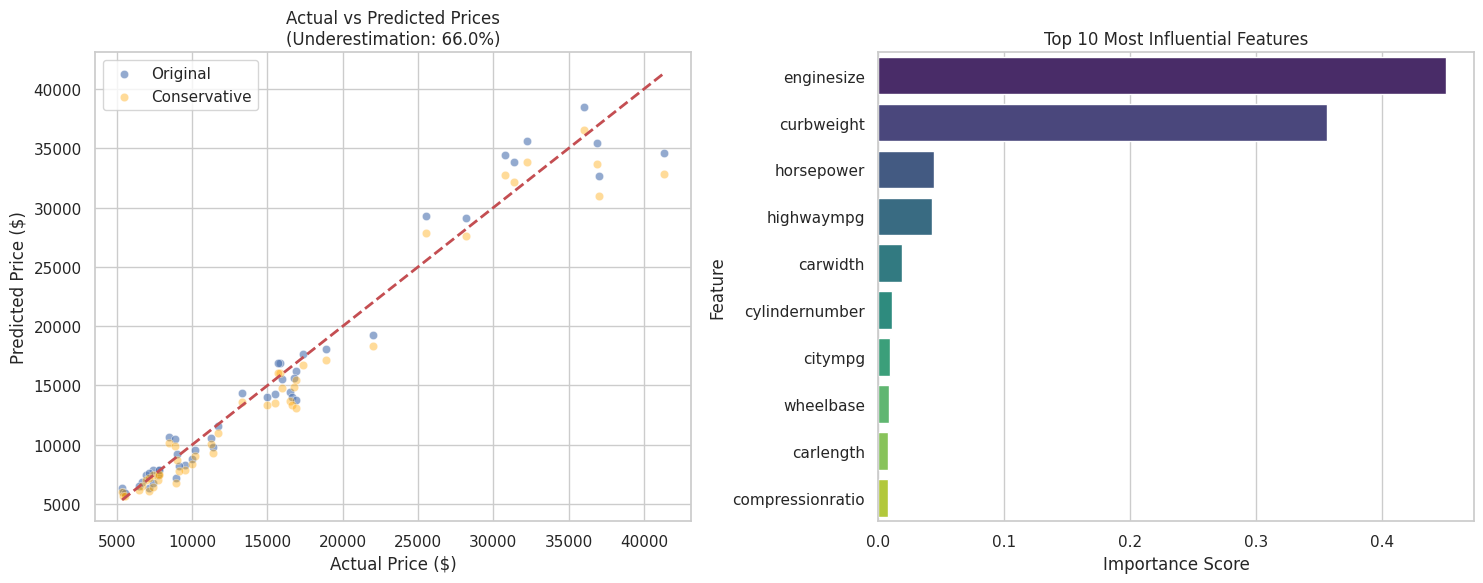

In [0]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- ORIGINAL RESULTS ---
predictions = model.predict(X_test)

print("-" * 30)
print("Original Model Performance:")
print(f"R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, predictions):.2f}")
print("-" * 30)

# --- BUSINESS LOGIC: UNDERESTIMATION ---
# PURPOSE: Apply a 5% 'Safety Buffer' to meet the business requirement of underestimation.
conservative_predictions = predictions * 0.95

print("Business-Optimized Results (Conservative):")
print(f"R2 Score: {r2_score(y_test, conservative_predictions):.4f}")
print(f"MAE: ${mean_absolute_error(y_test, conservative_predictions):.2f}")

# Check how many cases actually resulted in underestimation
underestimated_count = (conservative_predictions < y_test).sum()
pct_underestimated = (underestimated_count / len(y_test)) * 100
print(f"Percentage of underestimated cars: {pct_underestimated:.1f}%")
print("-" * 30)

# --- VISUALIZATION ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, label='Original')
sns.scatterplot(x=y_test, y=conservative_predictions, alpha=0.4, color='orange', label='Conservative')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f"Actual vs Predicted Prices\n(Underestimation: {pct_underestimated:.1f}%)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.legend()

# Plot 2: Feature Importance
plt.subplot(1, 2, 2)
importances = model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(10)

sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title("Top 10 Most Influential Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Residual Analysis
A residual plot shows the difference between the actual and predicted values. 
- If the points are randomly scattered around the horizontal axis (zero line), the model is appropriate for the data.
- Any clear pattern (like a funnel shape) would suggest that the model's errors are not random and it might struggle with certain price ranges.

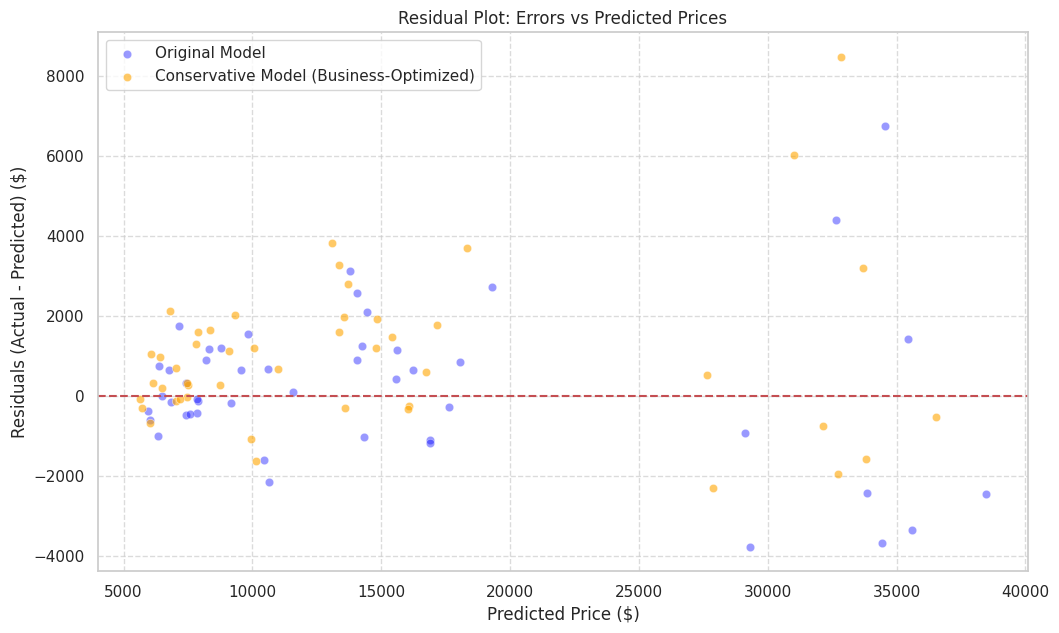

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# PURPOSE:
#   Calculate the difference between actual and predicted car prices 
#   for both original and conservative models to identify systematic errors.
residuals_original = y_test - predictions
residuals_conservative = y_test - conservative_predictions

# --- RESIDUAL PLOT ---
# PURPOSE:
#   Visualize the distribution of prediction errors.
# WHY:
#   By plotting both, we can see how the 5% buffer shifts the residuals 
#   above the zero line, confirming the underestimation goal.
plt.figure(figsize=(12, 7))

# Original residuals
sns.scatterplot(x=predictions, y=residuals_original, alpha=0.4, label='Original Model', color='blue')

# Conservative residuals
sns.scatterplot(x=conservative_predictions, y=residuals_conservative, alpha=0.6, label='Conservative Model (Business-Optimized)', color='orange')

plt.axhline(y=0, color='r', linestyle='--')

plt.title('Residual Plot: Errors vs Predicted Prices')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals (Actual - Predicted) ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Error Distribution
It shows whether the errors are, on average, close to zero (an unbiased model), and whether there are extreme outliers where the model completely misses the target. If the distribution is not bell-shaped (normally distributed), then the model’s underlying assumptions may be violated.

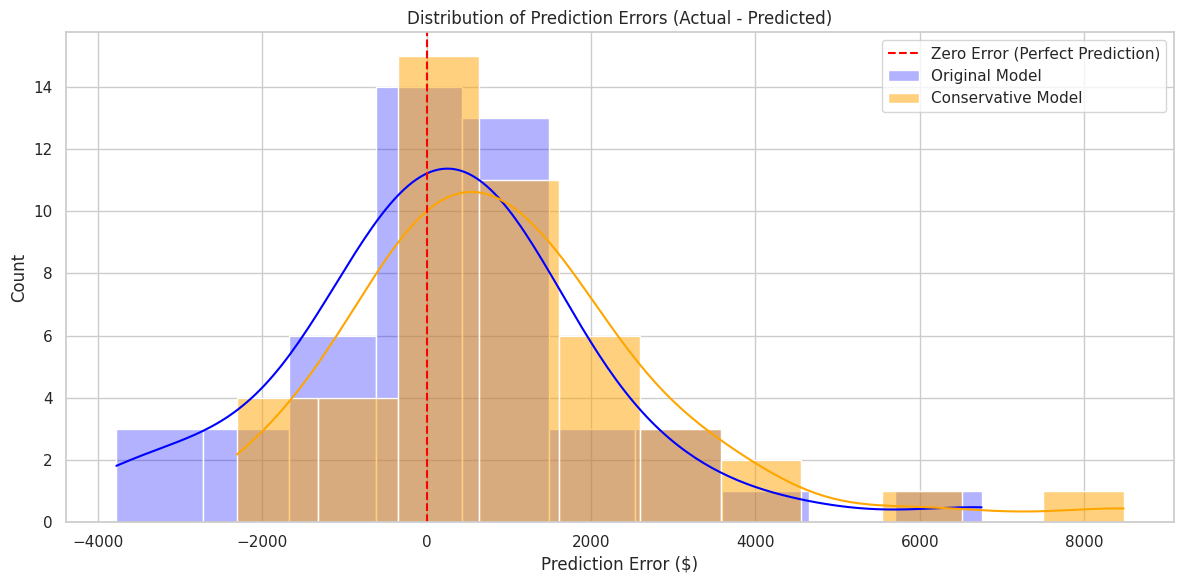

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# PURPOSE:
#   Visualize the distribution of errors for both models to verify the 'Underestimation' goal.
# WHY:
#   A shift in the distribution towards positive values indicates that actual prices 
#   are higher than predicted, confirming that the model is successfully underestimating.
residuals_original = y_test - predictions
residuals_conservative = y_test - conservative_predictions

plt.figure(figsize=(12, 6))

# Plot: Error Distribution Comparison
# WHY: Overlapping histograms allow for a direct comparison of the bias (error center) 
# between the standard model and the business-optimized version.
sns.histplot(residuals_original, kde=True, color='blue', label='Original Model', alpha=0.3)
sns.histplot(residuals_conservative, kde=True, color='orange', label='Conservative Model', alpha=0.5)

plt.axvline(x=0, color='red', linestyle='--', label='Zero Error (Perfect Prediction)')
plt.title('Distribution of Prediction Errors (Actual - Predicted)')
plt.xlabel('Prediction Error ($)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()